# Exploratory Data Analysis

## Objective

This notebook explores Barclays PLC (`BARC.L`) daily market data from **2015–2024** before feature engineering and modelling.

The objective is to predict whether the **next trading day's closing price will be higher than the current day's closing price**. The EDA therefore examines:

- data quality and sample coverage;
- closing-price and return behaviour;
- volatility through time; and
- the balance and stability of the binary target.

The analysis is descriptive, with no model selection performed at this stage.


## 1. Data collection and quality checks


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Download daily Barclays data from the London Stock Exchange.
ticker = "BARC.L"

data = yf.download(
    ticker,
    start="2015-01-01",
    end="2025-01-01",
    auto_adjust=False,
    progress=False
)

# yfinance can return MultiIndex columns even for a single ticker.
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[["Open", "High", "Low", "Close", "Volume"]].copy()
data.index.name = "Date"
data = data.sort_index()

# Save the raw OHLCV data used by the later notebooks.
data.to_csv("barclays_stock_data.csv")

print(f"Observations: {len(data):,}")
print(f"Period: {data.index.min().date()} to {data.index.max().date()}")
print(f"Duplicated dates: {data.index.duplicated().sum()}")
print("\nMissing values:")
print(data.isna().sum())

data.head()


Observations: 2,526
Period: 2015-01-02 to 2024-12-31
Duplicated dates: 0

Missing values:
Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,242.2000,245.6000,241.5500,243.1500,20219711
2015-01-05,242.3000,243.1500,234.2000,234.7000,39050852
2015-01-06,234.0500,235.8500,230.2500,230.3500,37573308
2015-01-07,232.1000,233.4600,230.1500,230.6000,37219841
2015-01-08,234.3000,238.3500,231.5500,237.0500,41082776


In [3]:
# Summary statistics for the raw market variables
data.describe().T


,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,"2,526.0000",181.1322,39.9947,80.0000,154.2550,175.2400,207.0000,287.5500
High,"2,526.0000",183.5722,40.1068,83.3100,156.5600,177.2600,209.4000,289.9000
Low,"2,526.0000",178.8742,39.8897,73.0400,152.5558,172.9200,205.1375,286.4000
Close,"2,526.0000",181.1668,39.9814,80.2400,154.2800,174.9100,207.0000,288.9500
Volume,"2,526.0000","49,469,760.6778","29,335,123.5476","1,549,882.0000","31,091,014.2500","41,800,881.5000","58,190,704.7500","345,720,341.0000"


### Initial findings

The downloaded sample contains **2,526 trading days from 2 January 2015 to 31 December 2024**, with **no missing observations and no duplicated dates**. 
The closing price averages **181.17** over the full period, but ranges from **80.24 to 288.95**, showing that Barclays traded across very different price regimes during the decade. Trading volume is also highly dispersed: the median is approximately **41.8 million shares**, while the maximum exceeds **345.7 million**. 


## 2. Closing price through time


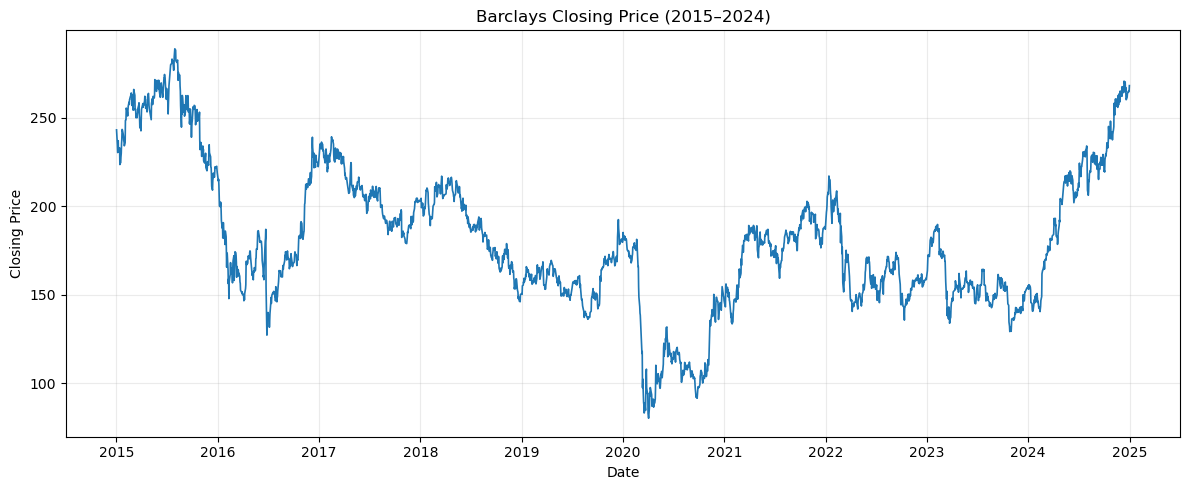

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Close"], linewidth=1.2)
ax.set(
    title="Barclays Closing Price (2015–2024)",
    xlabel="Date",
    ylabel="Closing Price"
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Price-level interpretation

The closing price changes substantially over the decade, indicating that the absolute price level is not stable over time. This supports using **returns and relative price measures** rather than relying on the raw price level.


## 3. Daily log returns


In [5]:
# Log returns convert multiplicative price changes into an additive series.
data["LogReturn"] = np.log(data["Close"] / data["Close"].shift(1))
returns = data["LogReturn"].dropna()

return_summary = pd.Series({
    "Mean": returns.mean(),
    "Standard deviation": returns.std(),
    "Minimum": returns.min(),
    "Maximum": returns.max(),
    "Skewness": returns.skew(),
    "Excess kurtosis": returns.kurt()
})

return_summary.to_frame("Value")


,Value
Mean,0.0000
Standard deviation,0.0217
Minimum,-0.1945
Maximum,0.1473
Skewness,-0.7596
Excess kurtosis,11.1615


### Table interpretation

Daily log returns have a mean very close to zero and a standard deviation of **2.17%**, showing substantial day-to-day variation around a small average return. The distribution is clearly non-Gaussian, with negative skewness (**-0.760**) and high excess kurtosis (**11.16**), indicating asymmetry and heavy tails. Furthermore, returns range from **-19.45%** to **14.73%**.

These results suggest that extreme returns are a feature of the distribution and shouldn't be removed solely because of their magnitude.

### Return distribution


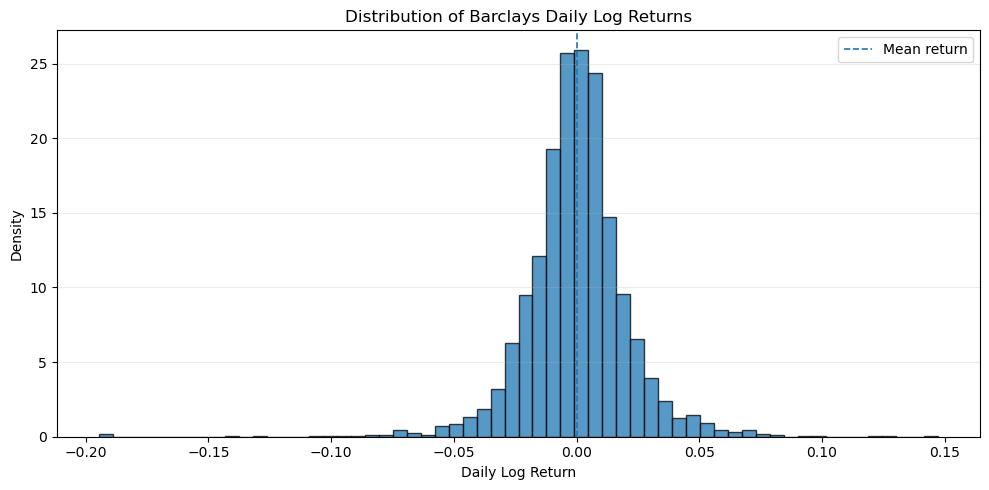

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(returns, bins=60, density=True, alpha=0.75, edgecolor="black")
ax.axvline(returns.mean(), linestyle="--", linewidth=1.2, label="Mean return")
ax.set(
    title="Distribution of Barclays Daily Log Returns",
    xlabel="Daily Log Return",
    ylabel="Density"
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Histogram interpretation

Most daily returns are concentrated around zero, with observations extending into both tails. The longer negative tail is consistent with the **-0.760 skewness**, while the concentration around zero alongside extreme observations is consistent with the high **11.16 excess kurtosis**.


### Returns through time


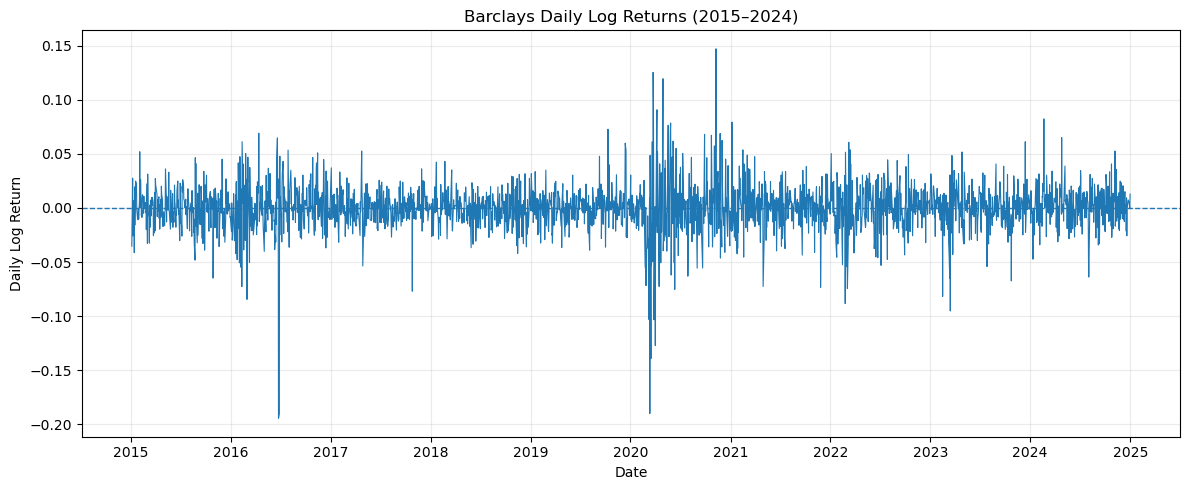

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["LogReturn"], linewidth=0.8)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(
    title="Barclays Daily Log Returns (2015–2024)",
    xlabel="Date",
    ylabel="Daily Log Return"
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Time-series interpretation

Daily returns fluctuate around approximately zero, but their dispersion is not constant through time. Quiet periods are interrupted by clusters of much larger positive and negative movements, with the clearest concentration around **2020**.


## 4. Rolling volatility


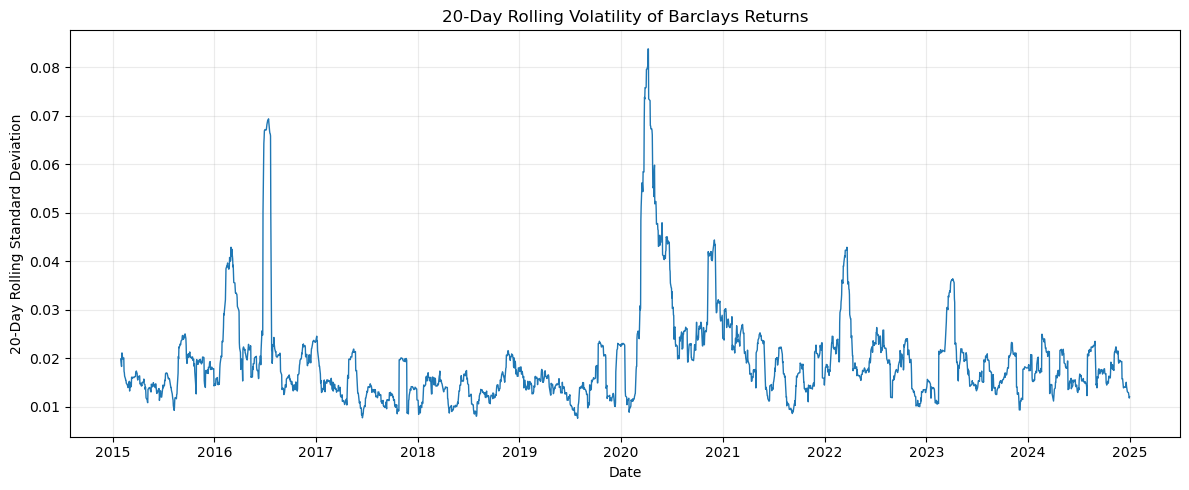

In [8]:
# A 20-trading-day window is approximately one trading month.
data["Vol20"] = data["LogReturn"].rolling(window=20).std()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(data.index, data["Vol20"], linewidth=1)
ax.set(
    title="20-Day Rolling Volatility of Barclays Returns",
    xlabel="Date",
    ylabel="20-Day Rolling Standard Deviation"
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Volatility interpretation

Above is a plot of the **20-day rolling volatility (Vol20)**, defined as the rolling standard deviation of daily log returns over the previous 20 trading days. It measures how variable returns have been over this period, with higher values indicating greater volatility.

The graph shows **volatility clustering**, where periods of high volatility tend to be followed by further high volatility. This is particularly evident in **2020**, where volatility rises sharply and remains elevated for several months rather than immediately returning to its previous level.

## 5. Short-horizon dependence in returns


In [9]:
# Examine whether recent returns contain simple linear dependence.
# These are descriptive diagnostics only; feature selection is not performed here.
lags = range(1, 11)

autocorr = pd.DataFrame({
    "Lag": list(lags),
    "Return autocorrelation": [returns.autocorr(lag=lag) for lag in lags],
    "Squared-return autocorrelation": [(returns ** 2).autocorr(lag=lag) for lag in lags]
})

autocorr


,Lag,Return autocorrelation,Squared-return autocorrelation
0,1,0.0239,0.2674
1,2,0.0141,0.1587
2,3,-0.0276,0.1493
3,4,-0.0196,0.1031
4,5,0.0044,0.1105
5,6,-0.0471,0.1409
6,7,0.0622,0.0873
7,8,0.0077,0.1311
8,9,-0.0190,0.1360
9,10,0.0206,0.0963


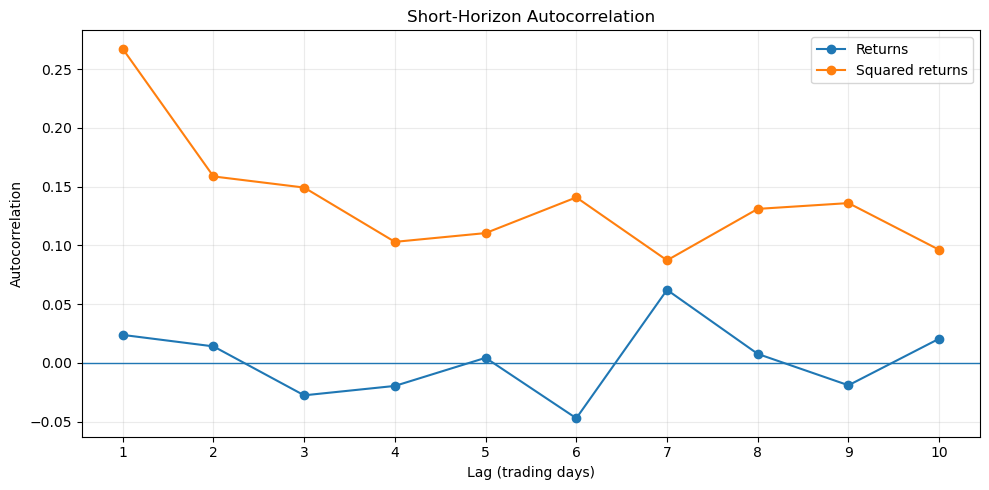

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    autocorr["Lag"],
    autocorr["Return autocorrelation"],
    marker="o",
    label="Returns"
)
ax.plot(
    autocorr["Lag"],
    autocorr["Squared-return autocorrelation"],
    marker="o",
    label="Squared returns"
)
ax.axhline(0, linewidth=1)
ax.set(
    title="Short-Horizon Autocorrelation",
    xlabel="Lag (trading days)",
    ylabel="Autocorrelation"
)
ax.set_xticks(list(lags))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Dependence interpretation

Raw-return autocorrelations are small across lags 1–10, suggesting little short-term linear dependence in returns. In contrast, squared-return autocorrelations remain positive across all lags, with the strongest relationship at **lag 1 (0.267)**. This supports the earlier evidence of **volatility clustering**, as the magnitude of returns shows greater persistence than their direction.


## 6. Target distribution


In [11]:
# Target = 1 if the next trading day's close is higher than today's close,
# otherwise Target = 0.
data["Target"] = (data["Close"].shift(-1) > data["Close"]).astype(int)

# The final row has no observable next-day outcome and must be excluded.
target_data = data.iloc[:-1].copy()

target_summary = pd.DataFrame({
    "Count": target_data["Target"].value_counts().sort_index(),
    "Percentage": (
        target_data["Target"].value_counts(normalize=True).sort_index() * 100
    )
})
target_summary.index = ["No increase (0)", "Increase (1)"]

target_summary


,Count,Percentage
No increase (0),1247,49.3861
Increase (1),1278,50.6139


### Target-balance interpretation

Across the full sample there are **1,278 upward next-day movements (50.61%)** and **1,247 non-upward movements (49.39%)**, so the classification problem is almost perfectly balanced. A naive classifier that always predicts the majority class (upward movement) would achieve only **50.61% accuracy**, meaning high accuracy cannot be obtained simply by exploiting class imbalance.


### Target balance through time


,Upward movements (%)
Date,
2015,47.8261
2016,54.1502
2017,47.2222
2018,49.0119
2019,51.7787
2020,46.8504
2021,52.5692
2022,47.2000
2023,52.5896


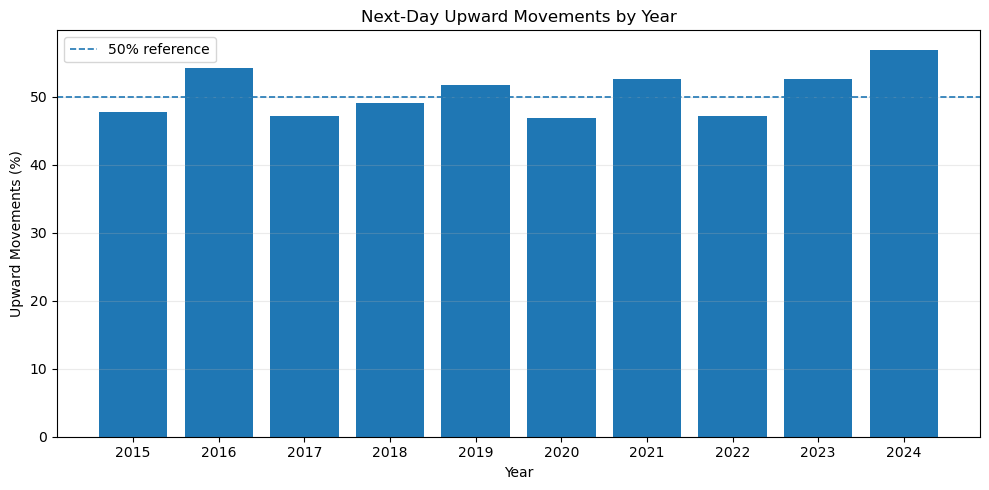

In [12]:
yearly_up_rate = (
    target_data["Target"]
    .groupby(target_data.index.year)
    .mean()
    .mul(100)
)

display(yearly_up_rate.rename("Upward movements (%)").to_frame())

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly_up_rate.index, yearly_up_rate.values)
ax.axhline(50, linestyle="--", linewidth=1.2, label="50% reference")
ax.set(
    title="Next-Day Upward Movements by Year",
    xlabel="Year",
    ylabel="Upward Movements (%)"
)
ax.set_xticks(yearly_up_rate.index)
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Target stability through time

The proportion of upward next-day movements varies across years, from **46.85% in 2020** to **56.92% in 2024**. Therefore, although the target is balanced overall, its distribution changes somewhat over time.



## 7. Summary and implications for modelling

The EDA highlights three main features of the data:

- Daily returns are noisy and heavy-tailed, with periods of substantially higher volatility.
- Raw returns show little short-term linear dependence, while squared returns show stronger persistence, consistent with **volatility clustering**.
- The target is balanced overall but varies somewhat across years, supporting the use of **chronological validation**.

